This function enables patterns generated via Ernould's method to be written to a .up2 file to enable processing by ATEX 

In [1]:
import numpy as np
import os
import sys

import ErnouldsMethod
#import write_up2
import conversions
import write_up2 as write_up2

sys.path.append('/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/PatternSimulation')
from PatternSimulation import SimPatGen as PG



In [2]:

detector_shape = (2400,2400)

In [3]:
def RunEBSDtorch(PC, E, D):
    PatG2 = PG.patternSimulation() #initializing the pattern generator
    masterpatternpath = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/Al_master_July222025.h5'
    PatG2.mastersetup(masterpatternpath) #setting the master pattern
    #change Euler and PC to float32 tensors
    PatG2.EandPCSet(E, PC) #setting the euler angles and pattern center
    SimPatInit = PatG2.GenPattern() #generating the pattern
    #extract the first row of SimPatInit
    SimPatInit = SimPatInit[0, :]
    SimPatInit = SimPatInit.cpu().detach().numpy()
    #flatten the pattern
    SimPatInit = SimPatInit.flatten()
    return SimPatInit

In [ ]:
E = np.array([np.deg2rad(75.0), np.deg2rad(125.0), np.deg2rad(15.0)])
PC = np.array([((1200-1.0)/2400), ((1200-240)/2400), (16000/(2400*20))]) #the pattern center for EBSDtorch is defined via EDAX convention 
#the z pc was calclated via L=16000/(1200*20)
EBSDtorch_Pattern = RunEBSDtorch(PC, E, np.eye(3))
mns = EBSDtorch_Pattern.min()
mxs = EBSDtorch_Pattern.max()
EBSDtorch_Pattern = np.around((EBSDtorch_Pattern - mns) / (mxs - mns) * 65535).astype(np.uint16)
#reshape the pattern to the detector shape
EBSDtorch_Pattern = EBSDtorch_Pattern.reshape(detector_shape)


Master Pattern Loaded
Initial Quaternions: Parameter containing:
tensor([[ 0.3265, -0.7682, -0.4435, -0.3265]], requires_grad=True)
Initial SE3 Vector: Parameter containing:
tensor([[-0.0000e+00,  3.4907e-01,  0.0000e+00, -8.1011e+02, -1.2005e+03,
          9.5932e+02]], requires_grad=True)


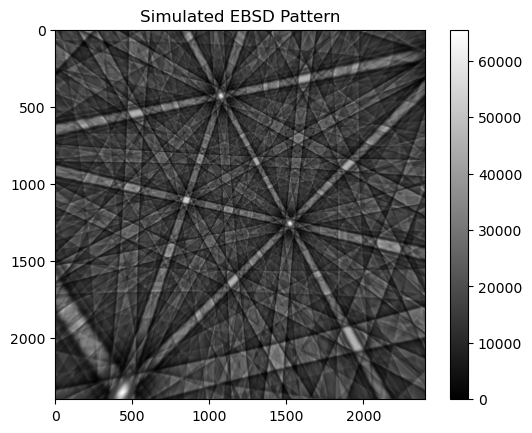

In [5]:
#plot the pattern
import matplotlib.pyplot as plt
plt.imshow(EBSDtorch_Pattern, cmap='gray')
plt.colorbar()
plt.title('Simulated EBSD Pattern')
plt.show()

In [6]:
EMEBSDfilename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb24-PC/AltPCx_pcx_1.00.h5'
EMEBSD_larger = ErnouldsMethod.read_EMEBSD(EMEBSDfilename)
Fe = np.eye(3) #the deformation gradient is identity since we are not considering any deformation in this case

# ref_coords = ErnouldsMethod.pattern_coords(Ernould_PC, detector_shape)
# EMEBSD_pattern = ErnouldsMethod.generate_patterns(Fe, Ernould_PC, ref_coords, EMEBSD_larger)
EMEBSD_pattern = EMEBSD_larger
mns = EMEBSD_pattern.min()
mxs = EMEBSD_pattern.max()
EMEBSD_pattern = np.around((EMEBSD_pattern - mns) / (mxs - mns) * 65535).astype(np.uint16)


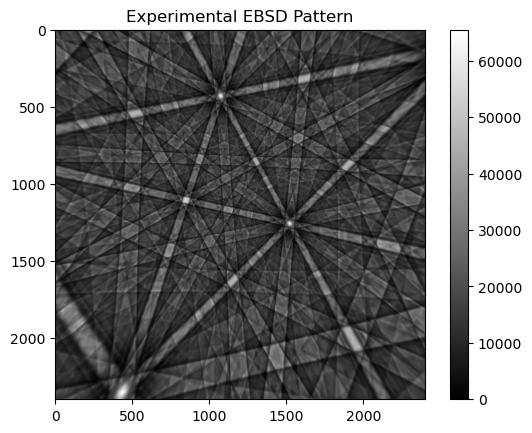

In [7]:
#plot the EMEBSD pattern
plt.imshow(EMEBSD_pattern, cmap='gray')
plt.colorbar()
plt.title('Experimental EBSD Pattern')
plt.show()



Simulated EBSD Pattern - Max Intensity: 65535, Mean Intensity: 16118.144066666666
Experimental EBSD Pattern - Max Intensity: 65535, Mean Intensity: 15781.021314583333


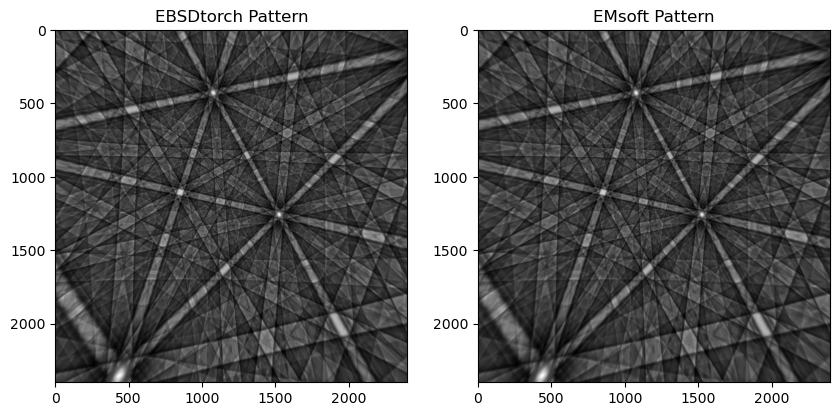

In [8]:
#plot the two patterns side by side for comparison
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(EBSDtorch_Pattern, cmap='gray')
axs[0].set_title('EBSDtorch Pattern')
axs[1].imshow(EMEBSD_pattern, cmap='gray')
axs[1].set_title('EMsoft Pattern')

#print the max and mean intensity values for both patterns belo w the plots
print(f"Simulated EBSD Pattern - Max Intensity: {np.max(EBSDtorch_Pattern)}, Mean Intensity: {np.mean(EBSDtorch_Pattern)}")
print(f"Experimental EBSD Pattern - Max Intensity: {np.max(EMEBSD_pattern)}, Mean Intensity: {np.mean(EMEBSD_pattern)}")
plt.show()

Structural Similarity

Structural Similarity Index (SSIM) between EBSDtorch and EMsoft patterns: 0.9071525942924692


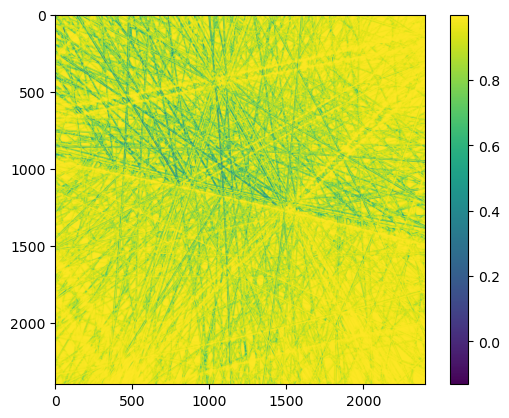

In [9]:
from skimage.metrics import structural_similarity as ssim

score, ssim_map = ssim(EBSDtorch_Pattern, EMEBSD_pattern, data_range=65535, full=True)
plt.imshow(ssim_map, cmap='viridis')
plt.colorbar()

print(f"Structural Similarity Index (SSIM) between EBSDtorch and EMsoft patterns: {score}")

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel

def plot_gradient_difference(img1, img2, cmap='seismic'):
    """
    Visualize directional differences between two images using gradient domain.

    Parameters
    ----------
    img1, img2 : 2D arrays
        Images to compare (must be same shape)
    cmap : str
        Colormap for signed differences
    """

    # --- ensure float ---
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    # --- compute gradients ---
    Ix1 = sobel(img1, axis=1)  # x-gradient (columns)
    Iy1 = sobel(img1, axis=0)  # y-gradient (rows)

    Ix2 = sobel(img2, axis=1)
    Iy2 = sobel(img2, axis=0)

    # --- gradient differences ---
    dx_err = Ix1 - Ix2
    dy_err = Iy1 - Iy2

    # --- symmetric color limits (VERY IMPORTANT) ---
    vmax = max(np.max(np.abs(dx_err)), np.max(np.abs(dy_err)))
    vmin = -vmax

    # --- plotting ---
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    im0 = ax[0].imshow(dx_err, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[0].set_title("Gradient difference (x)")
    ax[0].axis('off')
    fig.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(dy_err, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[1].set_title("Gradient difference (y)")
    ax[1].axis('off')
    fig.colorbar(im1, ax=ax[1], fraction=0.046)

    plt.tight_layout()
    plt.show()

    return dx_err, dy_err

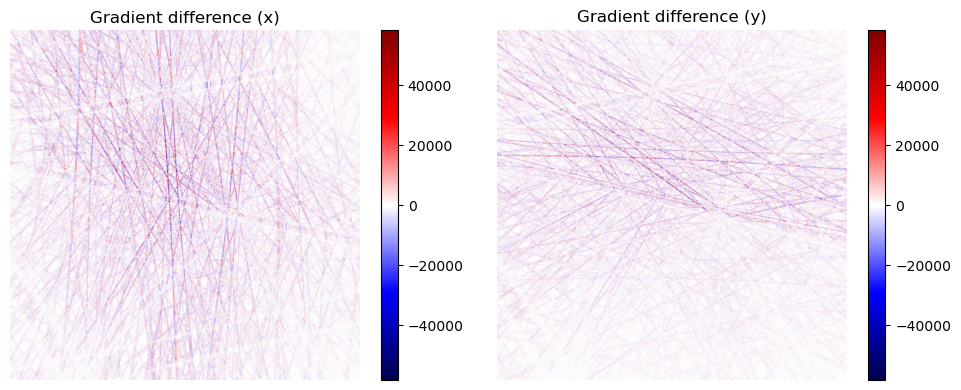

In [11]:
dx_err, dy_err = plot_gradient_difference(EBSDtorch_Pattern, EMEBSD_pattern)

In [12]:
sys.exit()

SystemExit: 

/Users/crestiennedechaine/opt/anaconda3/envs/hrebsd/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
Ernould_PC = np.array([600, 595, 16*1000/20]) #the pattern center to be used for Ernould's method
detector_shape = (1200,1200)

filepath = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/'
outputpath = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/PCx_onlyaltH32_OnePixSmallStep_Feb28.up2'


refpattern_path = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_0.00.h5'

# ----- File name for the strain cases --------
Testcasesfilename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/PC_Sensitivity_alteringh23.csv'

pc_values = np.arange(-1.0, 1.0 + 0.05, 0.05)

# choose which strain-case indices to include (0‑based); None means all
selected_cases = [0, 2] # e.g. [0, 2] to use only first and third cases

# Save statistics to CSV
csv_filename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/pattern_statistics_feb28.csv'

# number of patterns will be computed after loading/possibly slicing cases
numPats = None  # placeholder, overwritten later

In [ ]:
# numPats is computed later once the strain cases have been loaded/filtered
options = ['pcx']
cases = ['Case1', 'Case2', 'Case3', 'Case4', 'Case5', 'Case6', 'Case7', 'Case8', 'Case9', 'Case10', 'Case11', 'Case12', 'Case13', 'Case14', 'Case15', 'Case16']

In [ ]:
# pattern_filenames = []

# for option in options:
#     for case in cases:
#         #generate the string for the filename

#         filename = filepath + 'EBSD_' + option + '_' + case + '.h5'
#         pattern_filenames.append(filename)
#         print("Added pattern filename: ", filename)



pattern_filenames = []


print("PC values to be used: ", pc_values.shape)
print(pc_values)

for option in options:
    for pc in pc_values:
        # remove negative zero
        pc_clean = 0.0 if abs(pc) < 1e-12 else pc
        pc_str = f"{pc_clean:.2f}"

        filename = filepath + f"AltPCx_{option}_{pc_str}.h5"
        pattern_filenames.append(filename)

        print("Added pattern filename:", filename)




PC values to be used:  (41,)
[-1.0000000e+00 -9.5000000e-01 -9.0000000e-01 -8.5000000e-01
 -8.0000000e-01 -7.5000000e-01 -7.0000000e-01 -6.5000000e-01
 -6.0000000e-01 -5.5000000e-01 -5.0000000e-01 -4.5000000e-01
 -4.0000000e-01 -3.5000000e-01 -3.0000000e-01 -2.5000000e-01
 -2.0000000e-01 -1.5000000e-01 -1.0000000e-01 -5.0000000e-02
  8.8817842e-16  5.0000000e-02  1.0000000e-01  1.5000000e-01
  2.0000000e-01  2.5000000e-01  3.0000000e-01  3.5000000e-01
  4.0000000e-01  4.5000000e-01  5.0000000e-01  5.5000000e-01
  6.0000000e-01  6.5000000e-01  7.0000000e-01  7.5000000e-01
  8.0000000e-01  8.5000000e-01  9.0000000e-01  9.5000000e-01
  1.0000000e+00]
Added pattern filename: /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_-1.00.h5
Added pattern filename: /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_-0.95.h5
Added pattern filename: /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_-0.90.h5
Added pattern fil

Reading in the .csv file which contains all 12 of the strain cases

In [ ]:
testcases_data = np.genfromtxt(Testcasesfilename, delimiter=',', encoding='utf-8-sig')
            #breaking the testcases data into euler angles and strain/rotation components
        
w = testcases_data[:, 0:3]
e = testcases_data[:, 3:]

print('w', w)

print ("Number of test cases loaded: ", w.shape[0])

# optionally select only a subset of cases using indices defined earlier
if selected_cases is not None:
    w = w[selected_cases]
    e = e[selected_cases]
    print(f"Using {len(selected_cases)} selected case(s): {selected_cases}")

# now that w has been filtered we can recompute how many patterns we'll make
numPats = len(pc_values) * w.shape[0]
print("Number of patterns to simulate: ", numPats)

#create the tensor Fe_values
Fe_values = np.zeros((w.shape[0], 3, 3), dtype=np.float32)
#calculate the Fe values for each test case
for i in range(w.shape[0]):
    Fe_values[i, :, :] = ErnouldsMethod.determineF(e[i], w[i])
    #normalize so that h33 = 1
    Fe_values[i, :, :] = Fe_values[i, :, :]/Fe_values[i, 2, 2]

h = conversions.F2h(Fe_values, [0, 5, 16*1000/20]) 

#print the shape of h to make sure it is correct
print("Shape of h: ", h.shape)


w [[ 0.       0.       0.     ]
 [-0.00895  0.       0.     ]
 [-0.0179   0.       0.     ]
 [-0.0269   0.       0.     ]
 [-0.0358   0.       0.     ]
 [-0.0448   0.       0.     ]
 [-0.0537   0.       0.     ]
 [-0.0627   0.       0.     ]
 [-0.0716   0.       0.     ]
 [-0.0806   0.       0.     ]
 [-0.0895   0.       0.     ]
 [-0.0985   0.       0.     ]]
Number of test cases loaded:  12
Using 2 selected case(s): [0, 2]
Number of patterns to simulate:  82
Shape of h:  (8, 2)


In [ ]:
counter = 0 
generated_patterns = np.zeros((numPats, detector_shape[0], detector_shape[1]), dtype=np.float32)
stats_data = []  # Add this to collect stats

#for each of the filenames generate a pattern at each of the h values
for filename in pattern_filenames:
    print("Generating patterns for file: ", filename)
    EMEBSD_pattern = ErnouldsMethod.read_EMEBSD(filename)
    ref_coords = ErnouldsMethod.pattern_coords(Ernould_PC, detector_shape)
    for i in range(w.shape[0]):
        print("Generating pattern ", counter+1, " of ", numPats)
        Fe = Fe_values[i, :, :]
        pattern = ErnouldsMethod.generate_patterns(Fe, Ernould_PC, ref_coords, EMEBSD_pattern)
        #scaling to a bit depth of 16 bits for consistency with the write_up2 function
        mns = pattern.min()
        mxs = pattern.max()
        pattern = np.around((pattern - mns) / (mxs - mns) * 65535).astype(
            np.uint16
        )
        generated_patterns[counter, :, :] = pattern
        
        pat = generated_patterns[counter, :, :]


        print(
            f"Pattern {counter+1}: "
            f"min={pat.min():.3f}, "
            f"max={pat.max():.3f}, "
            f"mean={pat.mean():.3f}, "
            f"std={pat.std():.3f}"
        )
        
        # Extract PC value from counter
        pc_idx = counter // w.shape[0]
        pc_value = pc_values[pc_idx]
        
        # Collect statistics
        stats_data.append([counter, pc_value, i, pat.min(), pat.max(), pat.mean(), pat.std()])

        counter += 1

#replace the first pattern with a pattern with no deformation for reference
EMEBSD_pattern_ref = ErnouldsMethod.read_EMEBSD(refpattern_path)
ref_coords = ErnouldsMethod.pattern_coords(Ernould_PC, detector_shape)
Fe_identity = np.eye(3)
generated_patterns[0, :, :] = ErnouldsMethod.generate_patterns(Fe_identity, Ernould_PC, ref_coords, EMEBSD_pattern_ref)


stats_array = np.array(stats_data)
np.savetxt(csv_filename, stats_array, 
           delimiter=',',
           header='pattern_index,pc_value,strain_case,min_intensity,max_intensity,mean_intensity,std_intensity',
           comments='',
           fmt='%d,%f,%d,%.6f,%.6f,%.6f,%.6f')
print(f"Pattern statistics saved to {csv_filename}")

Generating patterns for file:  /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_-1.00.h5
Generating pattern  1  of  82
Pattern 1: min=0.000, max=65535.000, mean=15630.242, std=6730.460
Generating pattern  2  of  82
Pattern 2: min=0.000, max=65535.000, mean=15618.620, std=6739.167
Generating patterns for file:  /Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Feb27-PC/AltPCx_pcx_-0.95.h5
Generating pattern  3  of  82
Pattern 3: min=0.000, max=65535.000, mean=15636.325, std=6725.769
Generating pattern  4  of  82


KeyboardInterrupt: 

In [ ]:
#save every tenth pattern as a .png file to check
import matplotlib.pyplot as plt

#folder to save the images
output_folder = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/Patterns'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
for i in range(0, numPats, 10):
    plt.imsave(os.path.join(output_folder, f'pattern_{i:03d}.png'), generated_patterns[i], cmap='gray')
    

In [ ]:

write_up2.write_up2(generated_patterns, outputpath, bit_depth=16)